### **Лаба 1, краткая информация, что сделать, кто участвовал, какие части делал. вводную инфу добавить в общем**

### Импорт библиотек

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf # only for loading dataset
import os

### Loading and preprocess data

In [3]:
# Loading from Tensorflow.Keras
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [5]:
print(x_train.shape, # 60 thousand of handwritten digits in size 28 x 28 pixels (3D-array), values from 0 to 255
      y_train.shape) # 60 thousand of correct digits (1D-array), target variables

(60000, 28, 28) (60000,)


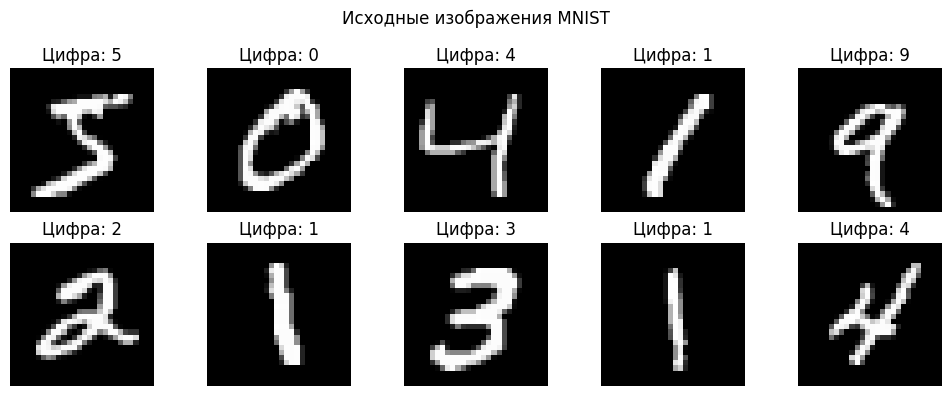

In [6]:
# vizualization of the dataset
def plot_images(images, labels, rows=2, cols=5, title=None):
    fig, axes = plt.subplots(rows, cols, figsize=(10,4))
    axes = axes.flatten()
    for i in range(rows*cols):
        axes[i].imshow(images[i], cmap='gray')
        axes[i].set_title(f"Цифра: {labels[i]}")
        axes[i].axis('off')
    if title: plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_images(x_train[:10], y_train[:10], title="Исходные изображения MNIST")

Визуализация вашего собственного датасета...


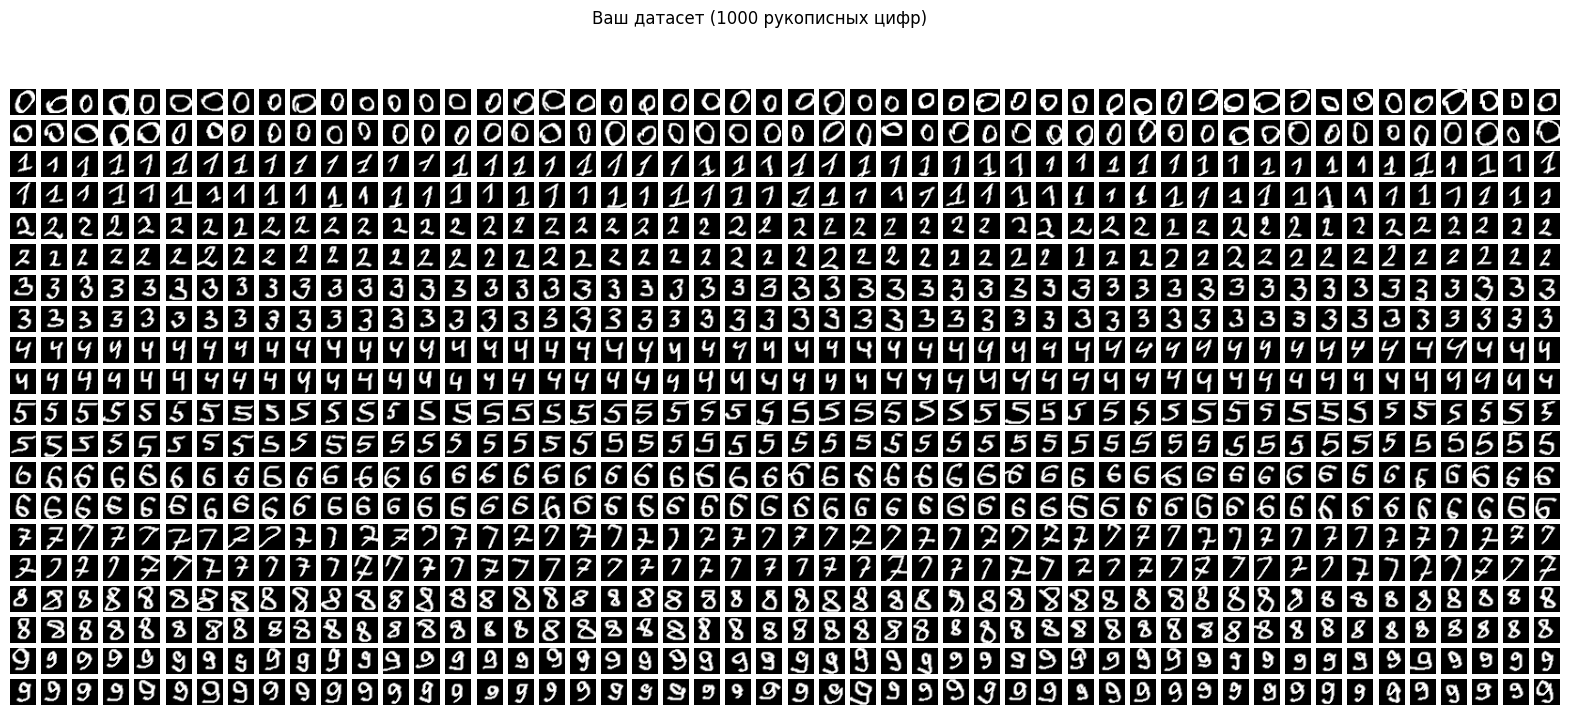

Новый размер обучающей выборки (MNIST + ваши данные): (61000, 784)
Размер обучающей выборки после обработки: (61000, 784)


In [9]:
# Нормализация
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# Преобразование в плоский вектор
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

custom_files = [
    '100 handwritten zeros.npy', '100 handwritten ones.npy', '100 handwritten twos.npy',
    '100 handwritten threes.npy', '100 handwritten fours.npy', '100 handwritten fives.npy',
    '100 handwritten sixes.npy', '100 handwritten sevens.npy', '100 handwritten eights.npy',
    '100 handwritten nines.npy'
]

all_custom_data = []

for file in custom_files:
    if os.path.exists(file):
        all_custom_data.append(np.load(file))
    else:
        print(f"Файл {file} не найден!")

# Объединяем ваши данные (1000 штук)
full_custom_array = np.vstack(all_custom_data)
y_custom = full_custom_array[:, 0].astype(int)
x_custom_flat = full_custom_array[:, 1:].astype(np.float32)

# Визуализация всего вашего датасета (1000 цифр: 20 рядов по 50 колонок)
print("Визуализация вашего собственного датасета...")
fig, axes = plt.subplots(20, 50, figsize=(20, 8))
axes = axes.flatten()
for i in range(1000):
    img = x_custom_flat[i].reshape(28, 28)
    axes[i].imshow(img, cmap="gray")
    axes[i].axis('off')
plt.suptitle("Ваш датасет (1000 рукописных цифр)")
plt.show()

# Объединяем с переменными x_train_flat и y_train, чтобы названия не менялись
x_train_flat = np.concatenate((x_train_flat, x_custom_flat), axis=0)
y_train = np.concatenate((y_train, y_custom), axis=0)

print(f"Новый размер обучающей выборки (MNIST + ваши данные): {x_train_flat.shape}")

# One-hot encoding
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

print("Размер обучающей выборки после обработки:", x_train_flat.shape)


def shift_image(image, dx, dy):
    img = image.reshape(28, 28)
    shifted = np.zeros_like(img)
    if dx > 0:
        shifted[:, dx:] = img[:, :-dx]
    elif dx < 0:
        shifted[:, :dx] = img[:, -dx:]
    else:
        shifted = img.copy()
    
    if dy > 0:
        shifted[dy:, :] = shifted[:-dy, :]
    elif dy < 0:
        shifted[:dy, :] = shifted[-dy:, :]
    
    return shifted.reshape(-1)

def augment_image(image):
    dx = np.random.randint(-2, 3)
    dy = np.random.randint(-2, 3)
    return shift_image(image, dx, dy)

def get_augmented_batch(X, y, size=5000):
    indices = np.random.choice(len(X), size, replace=False)
    x_aug = np.array([augment_image(X[i]) for i in indices])
    y_aug = y[indices]
    return x_aug, y_aug

x_aug, y_aug = get_augmented_batch(x_train_flat, y_train, size=10000)
y_aug_onehot = one_hot(y_aug)

x_train_extended = np.concatenate((x_train_flat, x_aug))
y_train_extended = np.concatenate((y_train_onehot, y_aug_onehot))

### Neural Network classes definition


In [39]:
class Layer:
    def forward(self, x): pass
    def backward(self, grad_output): pass

class Linear(Layer):
    def __init__(self, in_features, out_features):
        limit = np.sqrt(6 / (in_features + out_features))
        self.W = np.random.uniform(-limit, limit, (in_features, out_features))
        self.b = np.zeros((1, out_features))
        self.grad_W = self.grad_b = self.x = None

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, grad_output):
        self.grad_W = self.x.T @ grad_output
        self.grad_b = np.sum(grad_output, axis=0, keepdims=True)
        return grad_output @ self.W.T

### Функции активации

In [40]:
class ReLU(Layer):
    def forward(self, x):
        self.mask = (x > 0)
        return x * self.mask
    def backward(self, grad_output):
        return grad_output * self.mask

class Tanh(Layer):
    def forward(self, x):
        self.out = np.tanh(x)
        return self.out
    def backward(self, grad_output):
        return grad_output * (1 - self.out**2)

class Heaviside(Layer):
    def forward(self, x):
        return (x >= 0).astype(np.float32)
    def backward(self, grad_output):
        return np.zeros_like(grad_output)

### Функции потерь

In [41]:
class SoftmaxCrossEntropyLoss(Layer):
    def forward(self, logits, y_true):
        self.y_true = y_true
        self.batch_size = logits.shape[0]
        logits_shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp_logits = np.exp(logits_shifted)
        self.softmax = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
        loss = -np.sum(y_true * np.log(self.softmax + 1e-15)) / self.batch_size
        return loss
    def backward(self):
        return (self.softmax - self.y_true) / self.batch_size

class MSELoss(Layer):
    def forward(self, y_pred, y_true):
        self.y_pred = y_pred
        self.y_true = y_true
        self.batch_size = y_pred.shape[0]
        return np.mean((y_pred - y_true)**2)
    def backward(self):
        return 2 * (self.y_pred - self.y_true) / self.batch_size

### Sequential и оптимизатор SGD

In [42]:
class Sequential:
    def __init__(self, layers): self.layers = layers
    def forward(self, x):
        for layer in self.layers: x = layer.forward(x)
        return x
    def backward(self, grad):
        for layer in reversed(self.layers): grad = layer.backward(grad)
    def parameters(self):
        return [(l.W, l.b) for l in self.layers if hasattr(l, 'W')]
    def gradients(self):
        return [(l.grad_W, l.grad_b) for l in self.layers if hasattr(l, 'grad_W')]

class SGD:
    def __init__(self, parameters, lr=0.01):
        self.parameters = parameters
        self.lr = lr
    def step(self, grads):
        for (W, b), (gW, gb) in zip(self.parameters, grads):
            W -= self.lr * gW
            b -= self.lr * gb

### Функция обучения модели

In [43]:
def train_model(layers, loss_fn, lr=0.1, epochs=15, batch_size=64):
    model = Sequential(layers)
    optimizer = SGD(model.parameters(), lr=lr)
    num_batches = x_train_flat.shape[0] // batch_size
    train_losses = []
    test_accs = []
    
    for epoch in range(epochs):
        idx = np.random.permutation(x_train_flat.shape[0])
        x_shuf = x_train_flat[idx]
        y_shuf = y_train_onehot[idx]
        epoch_loss = 0.0
        
        for b in range(num_batches):
            xb = x_shuf[b*batch_size:(b+1)*batch_size]
            yb = y_shuf[b*batch_size:(b+1)*batch_size]
            out = model.forward(xb)
            loss = loss_fn.forward(out, yb)
            grad = loss_fn.backward()
            model.backward(grad)
            optimizer.step(model.gradients())
            epoch_loss += loss
        
        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)
        
        # Тестовая точность
        test_out = model.forward(x_test_flat)
        preds = np.argmax(test_out, axis=1)
        acc = np.mean(preds == y_test)
        test_accs.append(acc)
        
        print(f"Эпоха {epoch+1}: loss={avg_loss:.4f} test_acc={acc:.4f}")
    
    return train_losses, test_accs, model

### Модель 1: ReLU + CrossEntropy

Эпоха 1: loss=0.3412 test_acc=0.9490
Эпоха 2: loss=0.1516 test_acc=0.9578
Эпоха 3: loss=0.1069 test_acc=0.9696
Эпоха 4: loss=0.0823 test_acc=0.9739
Эпоха 5: loss=0.0667 test_acc=0.9742
Эпоха 6: loss=0.0545 test_acc=0.9775
Эпоха 7: loss=0.0454 test_acc=0.9774
Эпоха 8: loss=0.0387 test_acc=0.9797
Эпоха 9: loss=0.0324 test_acc=0.9786
Эпоха 10: loss=0.0273 test_acc=0.9786
Эпоха 11: loss=0.0226 test_acc=0.9795
Эпоха 12: loss=0.0198 test_acc=0.9791
Эпоха 13: loss=0.0162 test_acc=0.9801
Эпоха 14: loss=0.0132 test_acc=0.9803
Эпоха 15: loss=0.0101 test_acc=0.9793


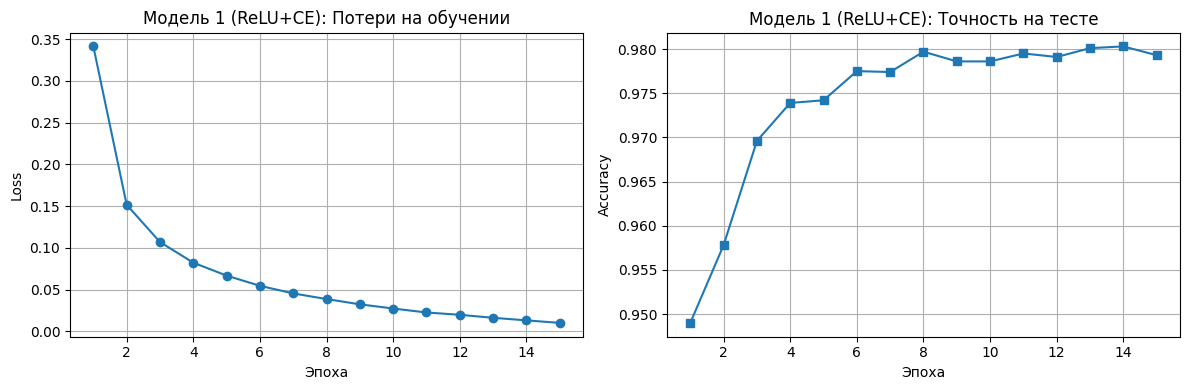

In [44]:
model1_layers = [
    Linear(784, 128),
    ReLU(),
    Linear(128, 64),
    ReLU(),
    Linear(64, 10)
]
loss_fn1 = SoftmaxCrossEntropyLoss()
train_loss1, test_acc1, model1 = train_model(model1_layers, loss_fn1, lr=0.1, epochs=15)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,16), train_loss1, marker='o')
plt.title('Модель 1 (ReLU+CE): Потери на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,16), test_acc1, marker='s')
plt.title('Модель 1 (ReLU+CE): Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

### Модель 2: Tanh + CrossEntropy

Эпоха 1: loss=0.3411 test_acc=0.9348
Эпоха 2: loss=0.1940 test_acc=0.9498
Эпоха 3: loss=0.1417 test_acc=0.9617
Эпоха 4: loss=0.1111 test_acc=0.9680
Эпоха 5: loss=0.0914 test_acc=0.9694
Эпоха 6: loss=0.0764 test_acc=0.9716
Эпоха 7: loss=0.0655 test_acc=0.9748
Эпоха 8: loss=0.0562 test_acc=0.9734
Эпоха 9: loss=0.0494 test_acc=0.9780
Эпоха 10: loss=0.0428 test_acc=0.9768
Эпоха 11: loss=0.0375 test_acc=0.9785
Эпоха 12: loss=0.0330 test_acc=0.9793
Эпоха 13: loss=0.0295 test_acc=0.9784
Эпоха 14: loss=0.0259 test_acc=0.9781
Эпоха 15: loss=0.0228 test_acc=0.9794


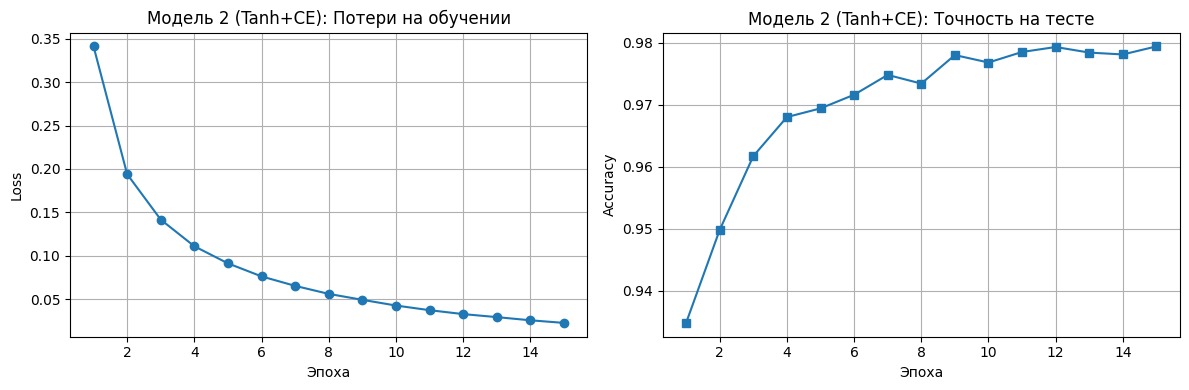

In [45]:
model2_layers = [
    Linear(784, 256),
    Tanh(),
    Linear(256, 128),
    Tanh(),
    Linear(128, 10)
]
loss_fn2 = SoftmaxCrossEntropyLoss()
train_loss2, test_acc2, model2 = train_model(model2_layers, loss_fn2, lr=0.1, epochs=15)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,16), train_loss2, marker='o')
plt.title('Модель 2 (Tanh+CE): Потери на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,16), test_acc2, marker='s')
plt.title('Модель 2 (Tanh+CE): Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

### Модель 3: Heaviside + CrossEntropy

Эпоха 1: loss=1.4403 test_acc=0.6074
Эпоха 2: loss=1.1938 test_acc=0.6150
Эпоха 3: loss=1.1703 test_acc=0.6178
Эпоха 4: loss=1.1631 test_acc=0.6189
Эпоха 5: loss=1.1588 test_acc=0.6200
Эпоха 6: loss=1.1568 test_acc=0.6201
Эпоха 7: loss=1.1553 test_acc=0.6206
Эпоха 8: loss=1.1550 test_acc=0.6234
Эпоха 9: loss=1.1531 test_acc=0.6211
Эпоха 10: loss=1.1532 test_acc=0.6234


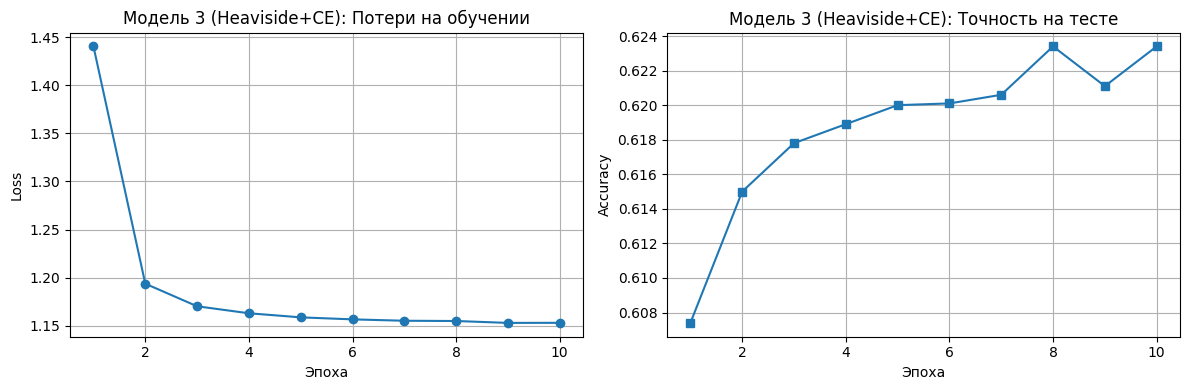

In [ ]:
model3_layers = [
    Linear(784, 128),
    Heaviside(),
    Linear(128, 64),
    Heaviside(),
    Linear(64, 10)
]
loss_fn3 = SoftmaxCrossEntropyLoss()
train_loss3, test_acc3, model3 = train_model(model3_layers, loss_fn3, lr=0.1, epochs=15)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,16), train_loss3, marker='o')
plt.title('Модель 3 (Heaviside+CE): Потери на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,16), test_acc3, marker='s')
plt.title('Модель 3 (Heaviside+CE): Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

### Модель 4: ReLU + MSE

Эпоха 1: loss=0.0240 test_acc=0.9391
Эпоха 2: loss=0.0123 test_acc=0.9526
Эпоха 3: loss=0.0098 test_acc=0.9573
Эпоха 4: loss=0.0084 test_acc=0.9622
Эпоха 5: loss=0.0075 test_acc=0.9627
Эпоха 6: loss=0.0068 test_acc=0.9654
Эпоха 7: loss=0.0063 test_acc=0.9649
Эпоха 8: loss=0.0059 test_acc=0.9668
Эпоха 9: loss=0.0056 test_acc=0.9675
Эпоха 10: loss=0.0053 test_acc=0.9671
Эпоха 11: loss=0.0050 test_acc=0.9683
Эпоха 12: loss=0.0048 test_acc=0.9691
Эпоха 13: loss=0.0045 test_acc=0.9680
Эпоха 14: loss=0.0043 test_acc=0.9686
Эпоха 15: loss=0.0042 test_acc=0.9699


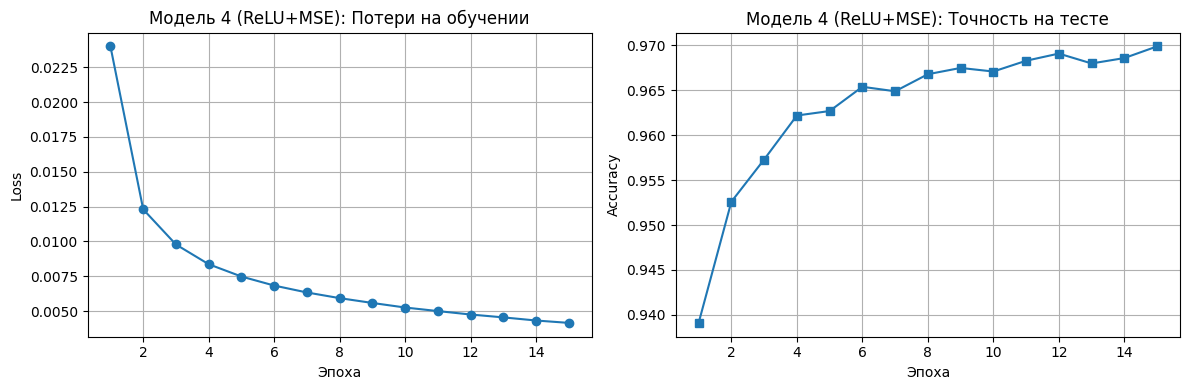

In [47]:
model4_layers = [
    Linear(784, 128),
    ReLU(),
    Linear(128, 64),
    ReLU(),
    Linear(64, 10)
]
loss_fn4 = MSELoss()
train_loss4, test_acc4, model4 = train_model(model4_layers, loss_fn4, lr=0.1, epochs=15)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,16), train_loss4, marker='o')
plt.title('Модель 4 (ReLU+MSE): Потери на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,16), test_acc4, marker='s')
plt.title('Модель 4 (ReLU+MSE): Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

### Модель 5: Tanh + MSE

Эпоха 1: loss=0.0469 test_acc=0.8872
Эпоха 2: loss=0.0297 test_acc=0.9155
Эпоха 3: loss=0.0247 test_acc=0.9282
Эпоха 4: loss=0.0221 test_acc=0.9356
Эпоха 5: loss=0.0203 test_acc=0.9420
Эпоха 6: loss=0.0191 test_acc=0.9442
Эпоха 7: loss=0.0181 test_acc=0.9472
Эпоха 8: loss=0.0172 test_acc=0.9503
Эпоха 9: loss=0.0165 test_acc=0.9528
Эпоха 10: loss=0.0159 test_acc=0.9556
Эпоха 11: loss=0.0154 test_acc=0.9545
Эпоха 12: loss=0.0149 test_acc=0.9577
Эпоха 13: loss=0.0144 test_acc=0.9574
Эпоха 14: loss=0.0140 test_acc=0.9578
Эпоха 15: loss=0.0137 test_acc=0.9593


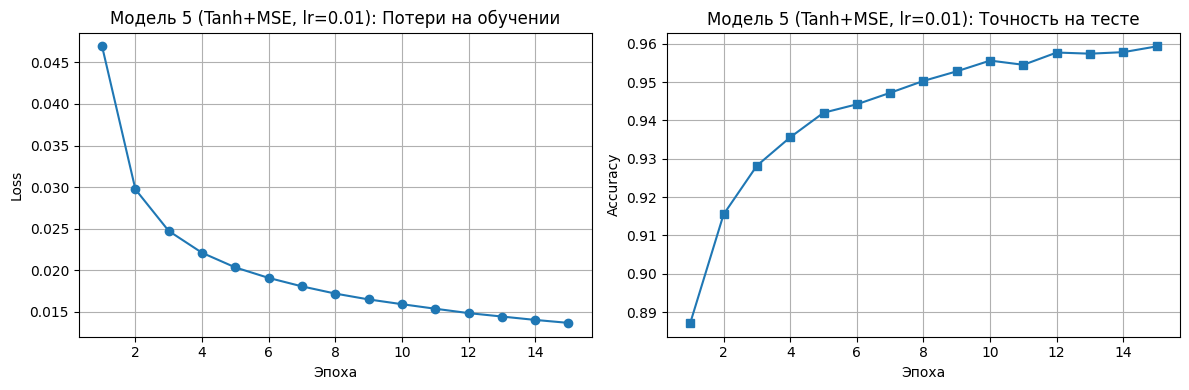

In [48]:
model5_layers = [
    Linear(784, 256),
    Tanh(),
    Linear(256, 128),
    Tanh(),
    Linear(128, 10)
]
loss_fn5 = MSELoss()
train_loss5, test_acc5, model5 = train_model(model5_layers, loss_fn5, lr=0.01, epochs=15)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,16), train_loss5, marker='o')
plt.title('Модель 5 (Tanh+MSE, lr=0.01): Потери на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,16), test_acc5, marker='s')
plt.title('Модель 5 (Tanh+MSE, lr=0.01): Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

### Модель 6: Heaviside + MSE

Эпоха 1: loss=0.1119 test_acc=0.4544
Эпоха 2: loss=0.0762 test_acc=0.4955
Эпоха 3: loss=0.0736 test_acc=0.4969
Эпоха 4: loss=0.0728 test_acc=0.5052
Эпоха 5: loss=0.0725 test_acc=0.5087
Эпоха 6: loss=0.0723 test_acc=0.5075
Эпоха 7: loss=0.0722 test_acc=0.5062
Эпоха 8: loss=0.0722 test_acc=0.5066
Эпоха 9: loss=0.0721 test_acc=0.4988
Эпоха 10: loss=0.0721 test_acc=0.5088


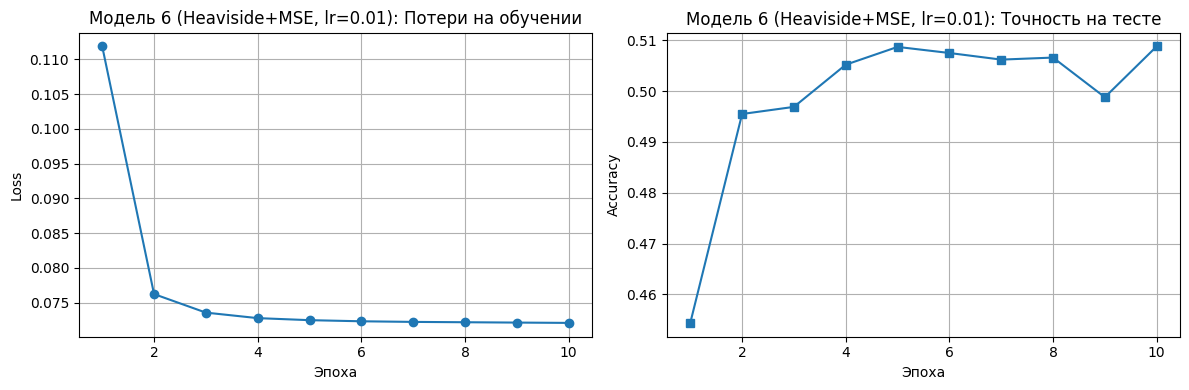

In [ ]:
model6_layers = [
    Linear(784, 128),
    Heaviside(),
    Linear(128, 64),
    Heaviside(),
    Linear(64, 10)
]
loss_fn6 = MSELoss()
train_loss6, test_acc6, model6 = train_model(model6_layers, loss_fn6, lr=0.01, epochs=15)

# График обучения модели 6
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,16), train_loss6, marker='o')
plt.title('Модель 6 (Heaviside+MSE, lr=0.01): Потери на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,16), test_acc6, marker='s')
plt.title('Модель 6 (Heaviside+MSE, lr=0.01): Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

### Сравнение всех моделей

ValueError: x and y must have same first dimension, but have shapes (15,) and (10,)

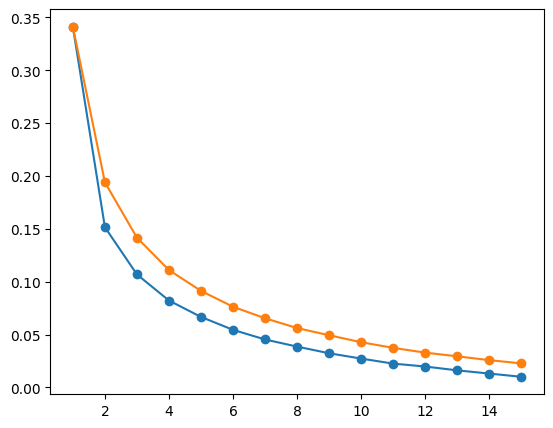

In [51]:
names = ["ReLU+CE", "Tanh+CE", "Heaviside+CE", "ReLU+MSE", "Tanh+MSE (lr=0.01)", "Heaviside+MSE (lr=0.01)"]
train_losses = [train_loss1, train_loss2, train_loss3, train_loss4, train_loss5, train_loss6]
test_accs = [test_acc1, test_acc2, test_acc3, test_acc4, test_acc5, test_acc6]

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
for i, name in enumerate(names):
    plt.plot(range(1,16), train_losses[i], marker='o', label=name)
plt.xlabel('Эпоха'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.title('Сравнение потерь на обучении')

plt.subplot(1,2,2)
for i, name in enumerate(names):
    plt.plot(range(1,16), test_accs[i], marker='s', label=name)
plt.xlabel('Эпоха'); plt.ylabel('Test Accuracy'); plt.legend(); plt.grid(True)
plt.title('Сравнение точности на тесте')

plt.tight_layout()
plt.show()

final_accs = [acc[-1] for acc in test_accs]
best_idx = np.argmax(final_accs)
best_name = names[best_idx]
best_acc = final_accs[best_idx]
best_model = [model1, model2, model3, model4, model5, model6][best_idx]

print(f"Лучшая модель: {best_name} с точностью {best_acc:.4f}")

best_preds = np.argmax(best_model.forward(x_test_flat), axis=1)

correct = np.where(best_preds == y_test)[0]
incorrect = np.where(best_preds != y_test)[0]

# Примеры правильных
plt.figure(figsize=(10,4))
for i, idx in enumerate(np.random.choice(correct, 5, replace=False)):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Истина: {y_test[idx]}\nПредск.: {best_preds[idx]}")
    plt.axis('off')
plt.suptitle("Примеры правильных предсказаний")
plt.tight_layout(); plt.show()

# Примеры неправильных
plt.figure(figsize=(10,4))
for i, idx in enumerate(np.random.choice(incorrect, 5, replace=False)):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Истина: {y_test[idx]}\nПредск.: {best_preds[idx]}")
    plt.axis('off')
plt.suptitle("Примеры неправильных предсказаний")
plt.tight_layout(); plt.show()